# Footprint-based Sex Prediction — Notebook Overview


## Stage 1: Load and Explore the Dataset (EDA) — What / Why / Outcome

In this stage we perform Exploratory Data Analysis (EDA). EDA helps us understand the data before building models. Below are the common tasks we perform and why they are useful:

1) Load the dataset: We read the CSV file into a table (called a DataFrame) so we can inspect and manipulate it.
   - Outcome: The data is available in memory for further steps.

2) Inspect basic information (shape, columns, datatypes): We check how many rows and columns there are and what type each column is (numbers, text, etc.).
   - Why: This reveals missing columns, unexpected types, or obvious data errors.

3) Display sample records and descriptive statistics: We look at a few rows and summary statistics (mean, std, min, max) for numeric columns.
   - Outcome: Helps to detect outliers and understand typical measurement ranges.

4) Missing value checks: Confirm whether there are empty or missing values that require cleaning.
   - Why: Missing data can break models or bias results. If missing values exist, we decide how to handle them (drop, fill, or estimate).

5) Target balance checks: We check how many samples belong to each sex and whether the dataset is balanced.
   - Outcome: Knowing class balance helps choose evaluation metrics and model strategies (e.g., balancing).

6) Correlation and visualizations: Heatmaps and histograms help us see relationships between features and the target.
   - Why: Highly correlated features may be redundant; some features might show strong differences between sexes which makes them useful for prediction.

By the end of this stage you should be able to answer: Is the data clean enough? Are there obvious predictive features? Is the target variable balanced?

Quick notes for non-technical readers:
- You do not need to understand every code line to follow the notebook — read the explanatory cells to learn the ideas.
- If you run into an error while executing a code cell, read the troubleshooting section near the end before asking for help.

Prerequisites (what to install):
- Python 3.8+ with packages listed in `requirements.txt` (pandas, numpy, scikit-learn, xgboost, seaborn, matplotlib, joblib).

How to run:
1. Run cells top-to-bottom in order.
2. When long-running steps appear (e.g., grid search), you can skip or run with smaller parameter grids.

Expected outcomes:
- Trained models saved to the `models` folder.
- Visual plots showing distributions, correlations, and model performance.
- A simple callable function at the end to predict sex for a single new footprint measurement.

If you are ready, continue to the next section where we import libraries and load the dataset.

In [6]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#### Overall Dataset EDA

In [7]:
# Step 2: Load the dataset
df = pd.read_excel(r"G:\My Drive\3. Carino\MSC\Dissertation\ML\Gender Prediction using FootPrints\dataset\dataset_150.xlsx")


In [8]:
# Step 3: Basic Dataset info
print("Dataset Shape:", df.shape)
print("-"*30)

print("\nColumn Names:\n", df.columns)
print("-"*30)

print("\nData Types:\n")
print("-"*30)

print(df.dtypes)


Dataset Shape: (150, 18)
------------------------------

Column Names:
 Index(['S_No', 'FootSide', 'Foot_Length_cm', 'Foot_Breadth_cm', 'Foot_Index',
       'Midfoot_Width_cm', 'Toe1_Length_cm', 'Toe2_Length_cm',
       'Toe3_Length_cm', 'Toe4_Length_cm', 'Toe5_Length_cm', 'Ball_Breadth_cm',
       'Breadth_Ball_index', 'Heel_Breadth_cm', 'Heel_Breadth_Index',
       'Arch_Length_cm', 'Arch_Index', 'Sex'],
      dtype='object')
------------------------------

Data Types:

------------------------------
S_No                    int64
FootSide               object
Foot_Length_cm        float64
Foot_Breadth_cm       float64
Foot_Index            float64
Midfoot_Width_cm      float64
Toe1_Length_cm        float64
Toe2_Length_cm        float64
Toe3_Length_cm        float64
Toe4_Length_cm        float64
Toe5_Length_cm        float64
Ball_Breadth_cm       float64
Breadth_Ball_index    float64
Heel_Breadth_cm       float64
Heel_Breadth_Index    float64
Arch_Length_cm        float64
Arch_Index  

In [9]:
# Step 4: Display sample records
display(df.head())


,S_No,FootSide,Foot_Length_cm,Foot_Breadth_cm,Foot_Index,Midfoot_Width_cm,Toe1_Length_cm,Toe2_Length_cm,Toe3_Length_cm,Toe4_Length_cm,Toe5_Length_cm,Ball_Breadth_cm,Breadth_Ball_index,Heel_Breadth_cm,Heel_Breadth_Index,Arch_Length_cm,Arch_Index,Sex
0,1,Left,23.0,8.0,34.8,2.4,22.4,22.5,21.2,19.9,18.5,8.3,37.1,4.6,20.5,7.5,0.16,Male
1,2,Left,23.7,7.0,29.5,1.6,22.5,21.5,20.5,19.5,18.5,8.8,39.1,5.0,22.2,9.0,0.10,Male
2,3,Left,23.5,8.3,35.3,0.5,23.6,23.6,22.5,21.5,19.3,8.9,37.7,4.5,19.1,8.5,0.04,Male
3,4,Left,22.3,7.7,34.5,1.3,22.5,22.5,22.0,21.0,19.4,8.8,39.1,4.4,19.6,8.0,0.09,Male
4,5,Left,23.8,8.5,35.7,2.0,23.7,22.7,22.0,21.3,19.9,9.4,39.7,5.2,21.9,8.0,0.12,Male


In [10]:
# remove unused columns like S_No
df.drop(columns=['S_No'], inplace=True)


In [11]:
# Step 5: Check for missing values
print("\nMissing Values:\n")
print(df.isnull().sum())



Missing Values:

FootSide              0
Foot_Length_cm        0
Foot_Breadth_cm       0
Foot_Index            0
Midfoot_Width_cm      0
Toe1_Length_cm        0
Toe2_Length_cm        0
Toe3_Length_cm        0
Toe4_Length_cm        0
Toe5_Length_cm        0
Ball_Breadth_cm       0
Breadth_Ball_index    0
Heel_Breadth_cm       0
Heel_Breadth_Index    0
Arch_Length_cm        0
Arch_Index            0
Sex                   0
dtype: int64


0 means there are no missing values in any row and column

In [12]:
# Step 6: Describe numeric columns
display(df.describe())


,Foot_Length_cm,Foot_Breadth_cm,Foot_Index,Midfoot_Width_cm,Toe1_Length_cm,Toe2_Length_cm,Toe3_Length_cm,Toe4_Length_cm,Toe5_Length_cm,Ball_Breadth_cm,Breadth_Ball_index,Heel_Breadth_cm,Heel_Breadth_Index,Arch_Length_cm,Arch_Index
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,23.215333,8.374667,36.340000,2.460667,23.088667,22.788000,21.970667,20.802667,19.324000,8.861333,38.334667,4.756667,20.609333,7.053333,0.148600
std,2.025036,0.885315,5.931748,1.229552,1.394839,1.352101,1.345564,1.320461,1.224892,1.058033,3.801359,0.529076,2.029658,2.021982,0.068434
min,8.000000,3.400000,15.600000,0.000000,19.300000,19.200000,18.400000,17.500000,16.500000,0.000000,0.000000,3.000000,14.500000,0.000000,0.000000
25%,22.300000,7.825000,34.500000,1.600000,22.400000,21.800000,21.000000,19.825000,18.500000,8.300000,37.025000,4.400000,19.100000,6.250000,0.110000
50%,23.250000,8.500000,36.000000,2.500000,23.000000,22.750000,22.000000,20.900000,19.400000,9.000000,38.600000,4.800000,20.600000,7.500000,0.150000
75%,24.400000,9.000000,37.700000,3.000000,24.075000,23.800000,23.000000,21.775000,20.375000,9.500000,39.975000,5.175000,22.175000,8.475000,0.180000
max,27.100000,10.400000,100.000000,6.300000,26.000000,25.500000,24.600000,23.400000,21.500000,10.600000,44.400000,5.900000,25.600000,10.600000,0.570000


In [13]:
# Step 7: Check Footside Counts
df['FootSide'].value_counts()


FootSide
Left     100
Right     50
Name: count, dtype: int64

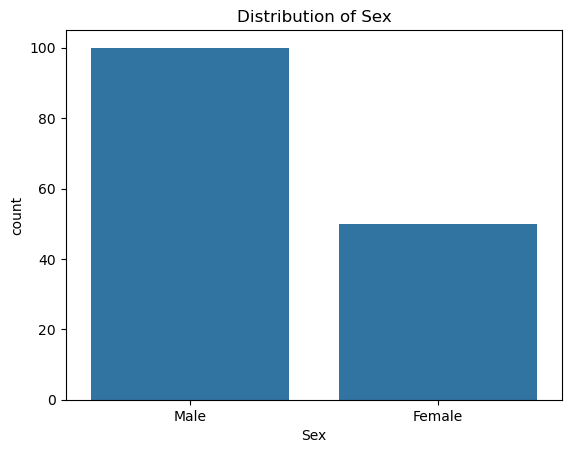

In [14]:
# Step 8: Count target variable (Sex) distribution
sns.countplot(x='Sex', data=df)
plt.title("Distribution of Sex")
plt.show()


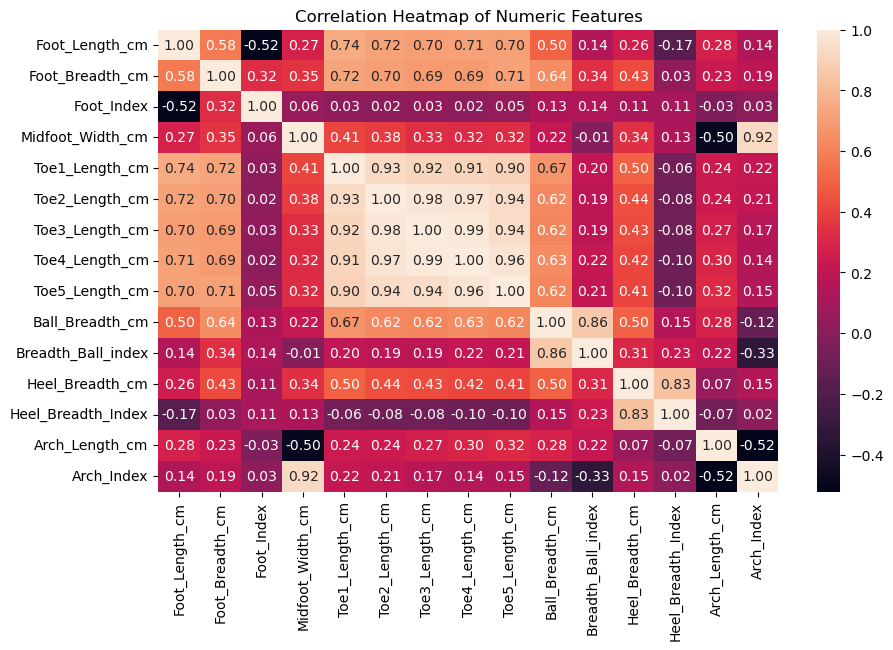

In [15]:
# --- Correlation Heatmap to check col to col relationship ---
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


In [16]:
# --- Statistical Mean by FootSide ---
foot_side_mean = df.groupby('FootSide').mean(numeric_only=True).T
display(foot_side_mean)


FootSide,Left,Right
Foot_Length_cm,22.7980,24.050
Foot_Breadth_cm,8.1570,8.810
Foot_Index,36.1870,36.646
Midfoot_Width_cm,2.3770,2.628
Toe1_Length_cm,22.8110,23.644
Toe2_Length_cm,22.5100,23.344
Toe3_Length_cm,21.6860,22.540
Toe4_Length_cm,20.5020,21.404
Toe5_Length_cm,19.0080,19.956
Ball_Breadth_cm,8.7210,9.142


In [17]:
# --- Statistical mean by Sex ---
sex_mean = df.groupby('Sex').mean(numeric_only=True).T
display(sex_mean)


Sex,Female,Male
Foot_Length_cm,21.6800,23.983
Foot_Breadth_cm,7.7500,8.687
Foot_Index,36.5740,36.223
Midfoot_Width_cm,2.4200,2.481
Toe1_Length_cm,22.0140,23.626
Toe2_Length_cm,21.7280,23.318
Toe3_Length_cm,20.8920,22.510
Toe4_Length_cm,19.6880,21.360
Toe5_Length_cm,18.2140,19.879
Ball_Breadth_cm,8.2900,9.147


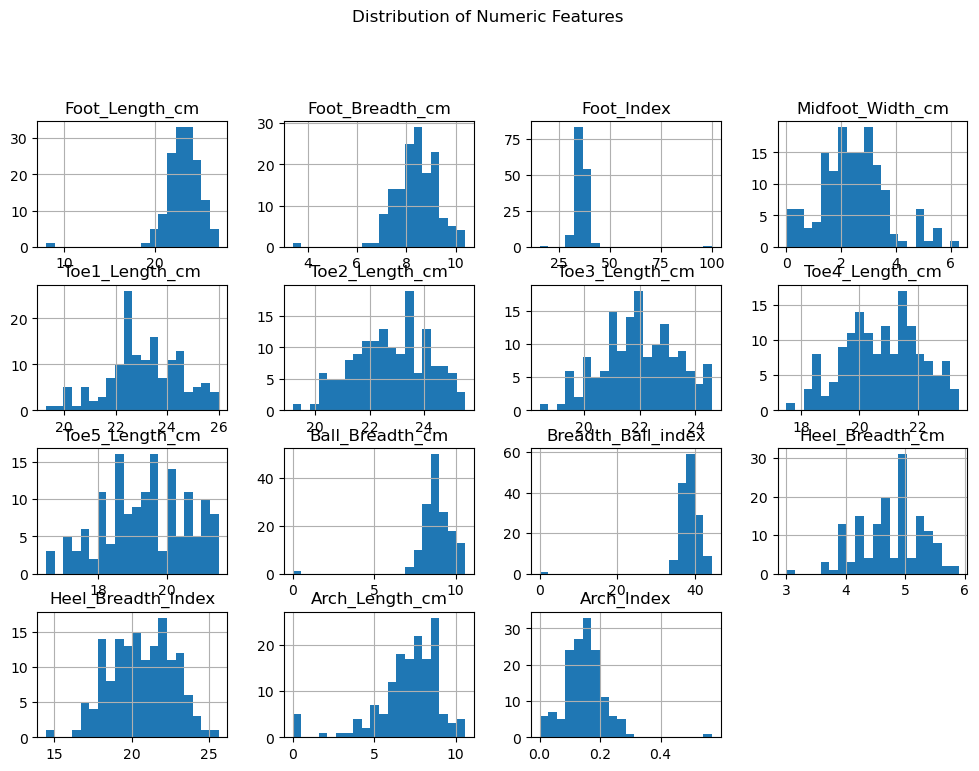

In [18]:
# --- Histograms for numeric features distribution ---
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution of Numeric Features", y=1.02)
plt.show()


C:\Users\jaina\AppData\Local\Temp\ipykernel_23732\838531861.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp[:10], y=feat_imp.index[:10], palette='viridis')


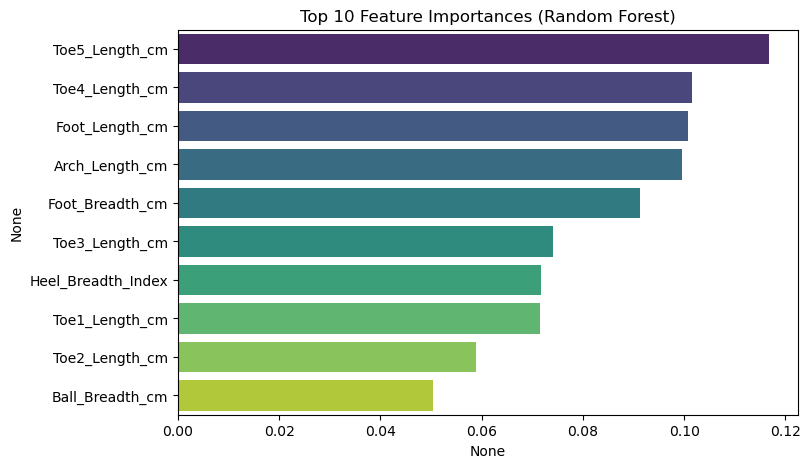

In [19]:
# Top 10 Important Features for whole dataset

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target
le = LabelEncoder()
y = le.fit_transform(df['Sex'])
# Exclude 'Sex' from features
X = df.drop('Sex', axis=1).select_dtypes(include=np.number)

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp[:10], y=feat_imp.index[:10], palette='viridis')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()


## Stage 2: Model Training & Evaluation Plan — What / Why / Outcome

In this stage we train several machine learning models and compare their performance.

What models we use and why:
- Decision Tree: A simple, easy-to-interpret model that splits data by feature thresholds. Good for baseline understanding.
- Random Forest: An ensemble of decision trees that reduces overfitting and generally performs well on tabular data.
- XGBoost: A powerful gradient boosting algorithm that often achieves high accuracy with careful tuning.
- Support Vector Machine (SVM) with RBF kernel: Effective for high-dimensional data; sensitive to feature scaling.

Evaluation approach and why it matters:
- We split the data into training and test sets. Models learn from the training set and are evaluated on the test set to estimate real-world performance.
- We use accuracy, precision, recall, and F1-score to provide multiple perspectives on performance.
- Confusion matrices show how many samples are correctly/incorrectly classified for each class.

Expected outcome:
- A short list of model performance numbers and visualizations so you can pick the most appropriate model for your needs (fast vs. accurate vs. interpretable).

---

#### Step 1 — Data Preparation (What / Why / Outcome)

What we will do:
- Convert categorical columns (like 'Sex' and 'FootSide') into numeric values so machine learning models can process them.
- Remove or ignore irrelevant columns (like serial numbers or IDs) that do not help prediction.
- Split the data into separate training and testing sets to evaluate how the model performs on new, unseen data.
- Scale features when needed (for example, Support Vector Machines are sensitive to feature scale).

Why these steps matter:
- Machine learning algorithms work with numbers only; converting categories to numbers is required.
- Using IDs or serial numbers confuses the model because they are arbitrary labels not related to the biological signal we want to learn.
- Splitting into training and testing prevents overfitting (where a model just memorizes the training data).
- Scaling keeps features on similar ranges; without scaling, algorithms like SVM may give undue importance to large-scale features.

Expected outcome:
- A cleaned and encoded dataset ready for training.
- Two datasets: one for training the models and one for evaluating them.

Notes for non-technical readers:
- 'Encoding' is the process of converting words (like 'Left'/'Right') into numbers (like 0/1).
- 'Scaling' is like converting all measurements to the same units so comparisons are fair.

In [27]:
df.head()


,FootSide,Foot_Length_cm,Foot_Breadth_cm,Foot_Index,Midfoot_Width_cm,Toe1_Length_cm,Toe2_Length_cm,Toe3_Length_cm,Toe4_Length_cm,Toe5_Length_cm,Ball_Breadth_cm,Breadth_Ball_index,Heel_Breadth_cm,Heel_Breadth_Index,Arch_Length_cm,Arch_Index,Sex
0,Left,23.0,8.0,34.8,2.4,22.4,22.5,21.2,19.9,18.5,8.3,37.1,4.6,20.5,7.5,0.16,Male
1,Left,23.7,7.0,29.5,1.6,22.5,21.5,20.5,19.5,18.5,8.8,39.1,5.0,22.2,9.0,0.10,Male
2,Left,23.5,8.3,35.3,0.5,23.6,23.6,22.5,21.5,19.3,8.9,37.7,4.5,19.1,8.5,0.04,Male
3,Left,22.3,7.7,34.5,1.3,22.5,22.5,22.0,21.0,19.4,8.8,39.1,4.4,19.6,8.0,0.09,Male
4,Left,23.8,8.5,35.7,2.0,23.7,22.7,22.0,21.3,19.9,9.4,39.7,5.2,21.9,8.0,0.12,Male


In [28]:
# --- Step 1A: Encode categorical columns ---
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df_encoded = df.copy()

# Label Encoding for categorical columns
label_cols = ['Sex', 'FootSide']
le = LabelEncoder()
for col in label_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])


In [29]:
df_encoded.head()


,FootSide,Foot_Length_cm,Foot_Breadth_cm,Foot_Index,Midfoot_Width_cm,Toe1_Length_cm,Toe2_Length_cm,Toe3_Length_cm,Toe4_Length_cm,Toe5_Length_cm,Ball_Breadth_cm,Breadth_Ball_index,Heel_Breadth_cm,Heel_Breadth_Index,Arch_Length_cm,Arch_Index,Sex
0,0,23.0,8.0,34.8,2.4,22.4,22.5,21.2,19.9,18.5,8.3,37.1,4.6,20.5,7.5,0.16,0
1,0,23.7,7.0,29.5,1.6,22.5,21.5,20.5,19.5,18.5,8.8,39.1,5.0,22.2,9.0,0.10,0
2,0,23.5,8.3,35.3,0.5,23.6,23.6,22.5,21.5,19.3,8.9,37.7,4.5,19.1,8.5,0.04,0
3,0,22.3,7.7,34.5,1.3,22.5,22.5,22.0,21.0,19.4,8.8,39.1,4.4,19.6,8.0,0.09,0
4,0,23.8,8.5,35.7,2.0,23.7,22.7,22.0,21.3,19.9,9.4,39.7,5.2,21.9,8.0,0.12,0


In [30]:
# --- Step 1B: Define X and y ---
X = df_encoded.drop(columns=['Sex', 'SubjectID'])
Y = df_encoded['Sex']


KeyError: "['SubjectID'] not found in axis"

In [ ]:
X.head()


,Age,FootSide,Foot_Length_mm,Foot_Breadth_mm,Ball_Breadth_mm,Heel_Breadth_mm,Toe1_Length_mm,Toe2_Length_mm,Toe3_Length_mm,Toe4_Length_mm,Toe5_Length_mm,Midfoot_Width_mm,Foot_Index_pct,Arch_Index,Heel_Angle_deg,Toe_Angle_deg
0,33,0,280.6,97.8,91.9,71.3,47.5,42.4,39.5,38.8,32.1,32.3,34.85,0.12,17.3,9.8
1,24,1,234.9,98.7,84.4,59.0,35.5,34.6,30.0,26.4,26.1,27.7,42.02,0.12,25.1,12.0
2,35,0,236.8,87.3,87.2,60.1,40.3,33.7,34.0,31.3,26.1,24.7,36.87,0.10,18.5,13.6
3,26,0,226.8,81.8,86.6,59.7,35.5,34.0,30.7,29.9,25.1,27.5,36.07,0.12,23.0,9.6
4,28,0,264.3,100.7,87.4,70.7,42.3,41.3,38.8,32.9,26.3,30.6,38.10,0.12,20.0,8.0


In [ ]:
Y.head()


0    1
1    0
2    0
3    0
4    1
Name: Sex, dtype: int64

In [ ]:
# --- Step 1C: Train–Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
X_train.head()


,Age,FootSide,Foot_Length_mm,Foot_Breadth_mm,Ball_Breadth_mm,Heel_Breadth_mm,Toe1_Length_mm,Toe2_Length_mm,Toe3_Length_mm,Toe4_Length_mm,Toe5_Length_mm,Midfoot_Width_mm,Foot_Index_pct,Arch_Index,Heel_Angle_deg,Toe_Angle_deg
3871,25,0,276.5,109.5,98.3,66.1,44.6,41.6,40.4,30.8,30.4,29.7,39.60,0.11,20.4,10.3
3494,21,1,245.2,101.1,88.6,61.5,39.3,32.7,32.8,30.4,28.5,27.3,41.23,0.11,21.6,11.3
4910,18,0,242.1,97.1,82.6,63.8,37.8,36.9,31.9,28.9,28.7,28.3,40.11,0.12,20.8,9.2
4318,25,0,288.7,105.4,93.6,66.8,47.3,45.0,38.1,36.2,32.3,28.1,36.51,0.10,24.7,10.2
5115,33,1,246.6,93.6,85.6,55.3,39.7,35.0,33.6,29.9,27.7,31.4,37.96,0.13,20.4,12.0


In [ ]:
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (4160, 16)
Test set: (1040, 16)


In [ ]:
# --- Step 1D: Scale features (Tree models don’t need it, but SVM does) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
X_train_scaled


array([[ 0.01594715, -0.99090673,  1.11571663, ..., -0.69324458,
        -0.20060218, -0.30353968],
       [-0.72944762,  1.00917672, -0.67780031, ..., -0.69324458,
         0.18018955,  0.15098862],
       [-1.2884937 , -0.99090673, -0.85543298, ...,  0.27418161,
        -0.0736716 , -0.80352081],
       ...,
       [ 0.57499323, -0.99090673, -1.16485763, ...,  0.27418161,
         2.46493992, -0.43989817],
       [ 0.57499323,  1.00917672,  0.39372579, ...,  0.27418161,
        -0.23233483,  0.19644145],
       [ 0.38864453,  1.00917672, -0.51162782, ..., -0.69324458,
        -1.81896703, -0.0308227 ]])

----

#### Step 2: Model Training

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
# Define models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True, random_state=42)
}


In [ ]:
# Store results
results = []



📘 Decision Tree Results:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       520
           1       0.97      0.97      0.97       520

    accuracy                           0.97      1040
   macro avg       0.97      0.97      0.97      1040
weighted avg       0.97      0.97      0.97      1040



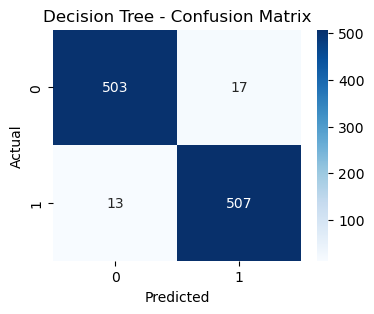


📘 Random Forest Results:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       520
           1       0.99      0.99      0.99       520

    accuracy                           0.99      1040
   macro avg       0.99      0.99      0.99      1040
weighted avg       0.99      0.99      0.99      1040



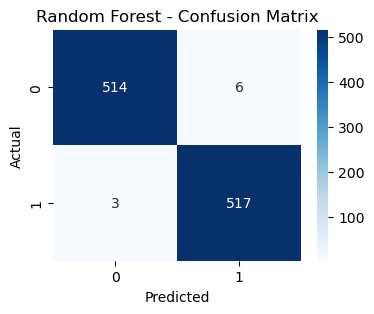


📘 XGBoost Results:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       520
           1       0.99      0.99      0.99       520

    accuracy                           0.99      1040
   macro avg       0.99      0.99      0.99      1040
weighted avg       0.99      0.99      0.99      1040



c:\Users\jaina\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:53:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


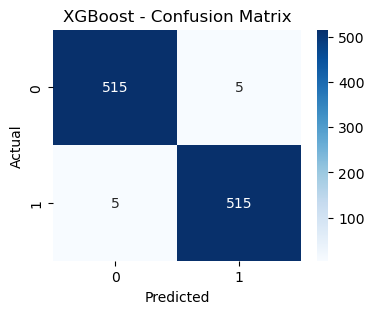


📘 SVM (RBF Kernel) Results:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       520
           1       0.99      0.99      0.99       520

    accuracy                           0.99      1040
   macro avg       0.99      0.99      0.99      1040
weighted avg       0.99      0.99      0.99      1040



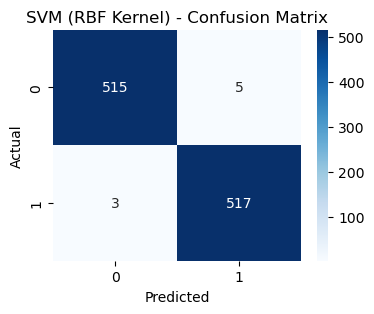

In [ ]:
# --- Step 2A: Train all models ---
for name, model in models.items():
    # Scale only for SVM
    if "SVM" in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

    print(f"\n📘 {name} Results:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [ ]:
# --- Step 2B: Model Comparison ---
results_df = pd.DataFrame(results)
display(results_df)


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.971154,0.967557,0.975000,0.971264
1,Random Forest,0.991346,0.988528,0.994231,0.991371
2,XGBoost,0.990385,0.990385,0.990385,0.990385
3,SVM (RBF Kernel),0.992308,0.990421,0.994231,0.992322


C:\Users\jaina\AppData\Local\Temp\ipykernel_23728\309670313.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


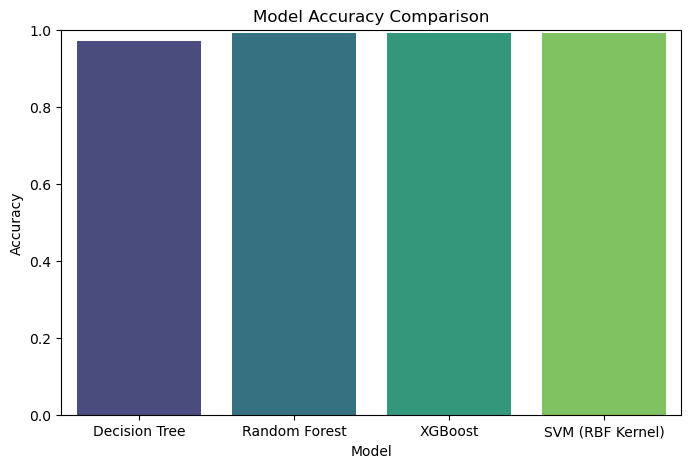

In [ ]:
# --- Step 2C: Visual Comparison ---
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()


---

### Step 3: Cross Validation — What / Why / Outcome

What we do:
- We use StratifiedKFold cross-validation which splits the training data into several folds, trains on some folds and validates on the remaining fold, repeating this process.

Why this helps:
- Cross-validation provides a more reliable estimate of model performance by averaging results over multiple splits, reducing the chance that the models apparent success is due to a lucky train/test split.
- StratifiedKFold keeps the class proportion the same in each fold which is important when classes are imbalanced.

Expected outcome:
- A mean cross-validation accuracy for each model and an estimate of variability (std). Models with high CV accuracy and low variance are preferred.

In [ ]:
# --- Step 3A: Cross-Validation (using StratifiedKFold) ---
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Use the same split for all models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}


In [ ]:
for name, model in models.items():
    if "SVM" in name:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    else:
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

    cv_results[name] = scores.mean()
    print(f"✅ {name} | CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")


✅ Decision Tree | CV Accuracy: 0.9601 ± 0.0052
✅ Random Forest | CV Accuracy: 0.9880 ± 0.0033


c:\Users\jaina\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:54:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\jaina\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:54:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\jaina\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:54:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\jaina\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:54:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

✅ XGBoost | CV Accuracy: 0.9880 ± 0.0042
✅ SVM (RBF Kernel) | CV Accuracy: 0.9873 ± 0.0031


In [ ]:
# Compare Cross Validation(CV) results
cv_df = pd.DataFrame(list(cv_results.items()), columns=['Model', 'CV Accuracy'])
display(cv_df)


,Model,CV Accuracy
0,Decision Tree,0.960096
1,Random Forest,0.987981
2,XGBoost,0.987981
3,SVM (RBF Kernel),0.987260


C:\Users\jaina\AppData\Local\Temp\ipykernel_23728\2805099818.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='CV Accuracy', data=cv_df, palette='mako')


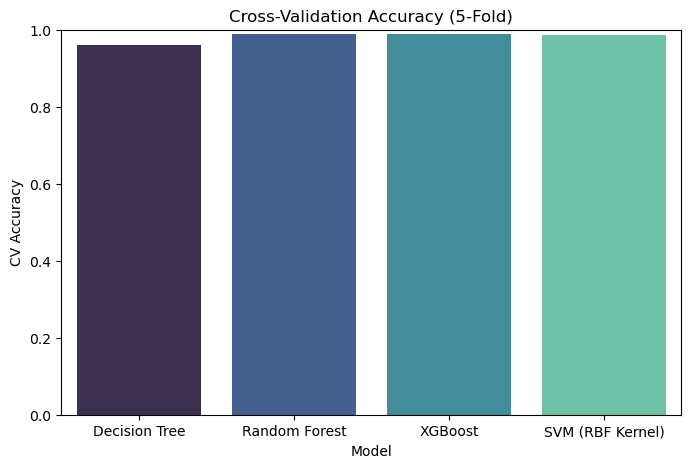

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='CV Accuracy', data=cv_df, palette='mako')
plt.title("Cross-Validation Accuracy (5-Fold)")
plt.ylim(0,1)
plt.show()


---

### Step 4: Hyperparameter Tuning (Grid Search) — What / Why / Outcome

What we do:
- We run GridSearchCV for Random Forest to search over combinations of hyperparameters (like number of trees, tree depth, etc.) and pick the combination that yields the best cross-validation accuracy.

Why it matters:
- Hyperparameters control how models learn. Choosing good hyperparameters often improves performance and generalization.

Important practical note (for beginners):
- Grid search can be slow depending on grid size and data. If you are using a laptop, consider reducing the number of parameter choices or using fewer CV folds.

Expected outcome:
- The best parameter combination and a tuned Random Forest model that is usually more accurate and robust than the default configuration.

In [ ]:
# --- Step 4: Hyperparameter Tuning for Random Forest ---
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)


In [ ]:
# --- Perdorming Tuning Search ---
# May take long time (5 min -1 hour)
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=2)

In [ ]:
print("✅ Best Parameters:", grid_search.best_params_)
print("🎯 Best CV Accuracy:", grid_search.best_score_)
print("🏆 Best Estimator:", grid_search.best_estimator_)


✅ Best Parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
🎯 Best CV Accuracy: 0.9899038461538462


In [ ]:
# Evaluate the best model
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("\nFinal Evaluation on Test Data:")
print(classification_report(y_test, y_pred_best))



Final Evaluation on Test Data:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       520
           1       0.99      0.99      0.99       520

    accuracy                           0.99      1040
   macro avg       0.99      0.99      0.99      1040
weighted avg       0.99      0.99      0.99      1040



## Stage 3: Feature Importance & Model Interpretability — What / Why / Outcome

Why interpretability matters:
- Knowing which features influence predictions helps us trust the model and extract domain insights (forensic or biometric importance).
- Feature importance from tree models (like Random Forest) suggests which measurements differ most between sexes.

What we will look at:
- Feature importance: a ranked list of features showing their relative contribution to predictions.
- Learning curves: show training vs. validation performance as we increase the training set size. Useful to diagnose overfitting or underfitting.
- ROC curve and AUC: help evaluate binary classifiers by measuring the trade-off between true positive rate and false positive rate at different thresholds.

Expected outcome:
- A short list of top features likely to be most predictive.
- Learning curves that indicate whether more data could improve performance (if validation score is still rising).
- AUC scores where values closer to 1.0 indicate excellent discrimination between classes.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [77]:
# Get feature importances
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]


In [78]:
# Feature names
features = X.columns

# Create DataFrame
fi_df = pd.DataFrame({
    'Feature': features[indices],
    'Importance': importances[indices]
})


C:\Users\jaina\AppData\Local\Temp\ipykernel_23728\912150649.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df.head(15), palette='crest')


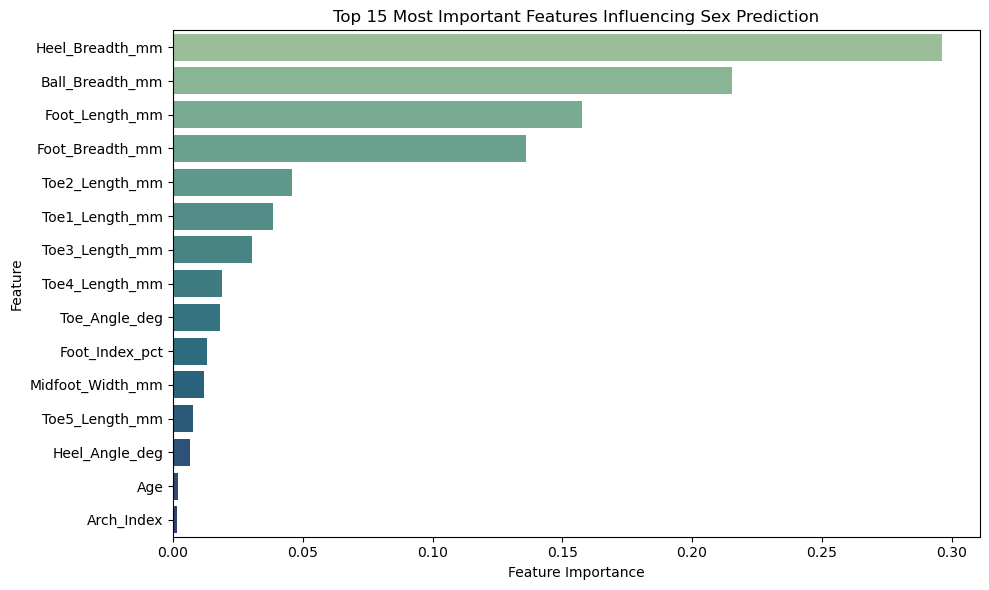

In [79]:
# Plot top 15 important features
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=fi_df.head(15), palette='crest')
plt.title("Top 15 Most Important Features Influencing Sex Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Learning Curves Analysis
Let's analyze how the model's performance changes with different training set sizes.

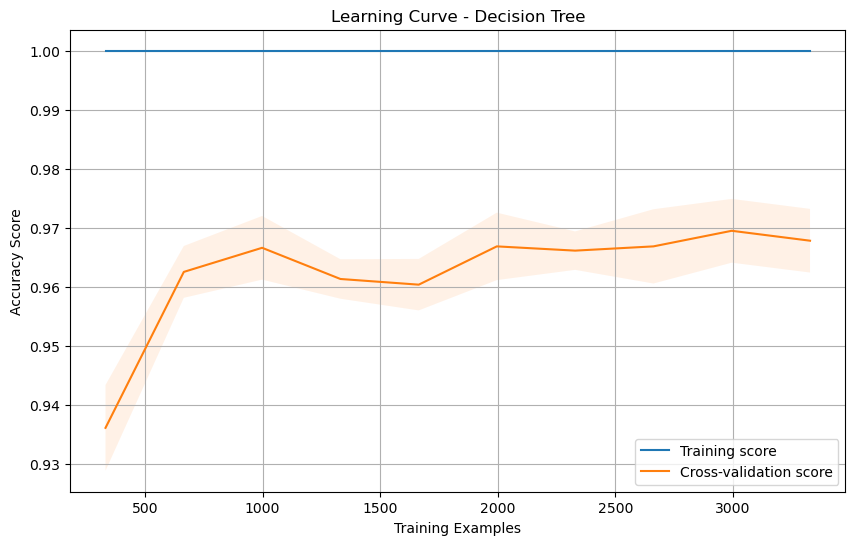

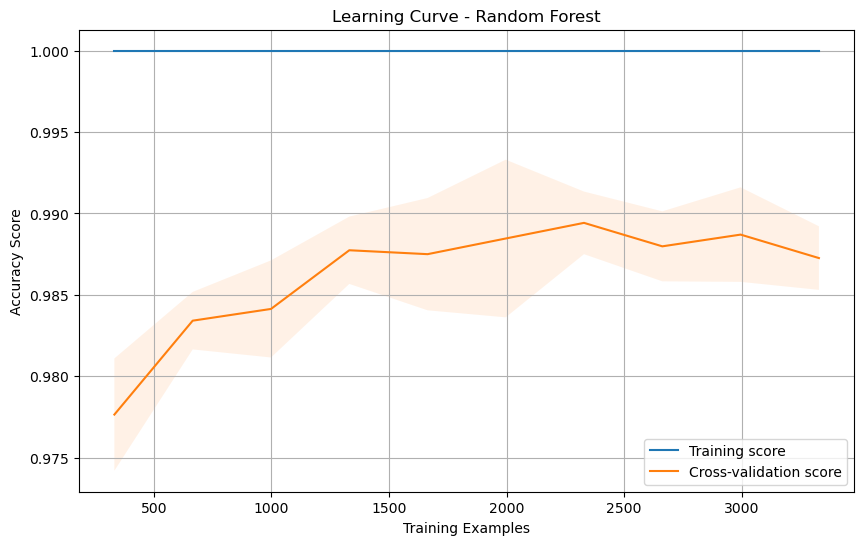

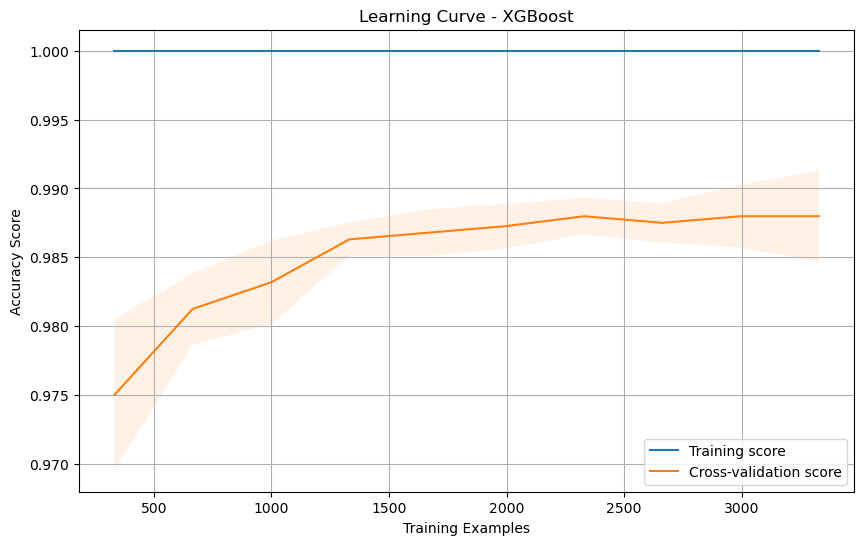

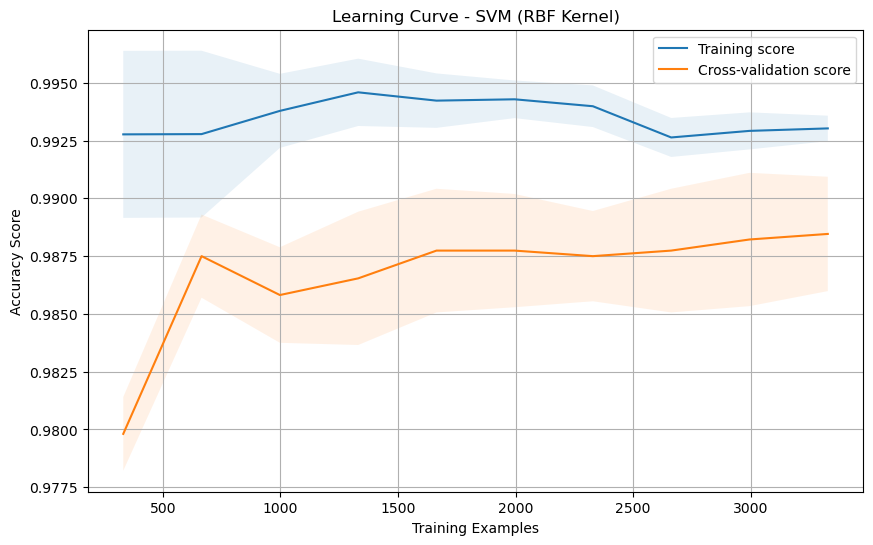

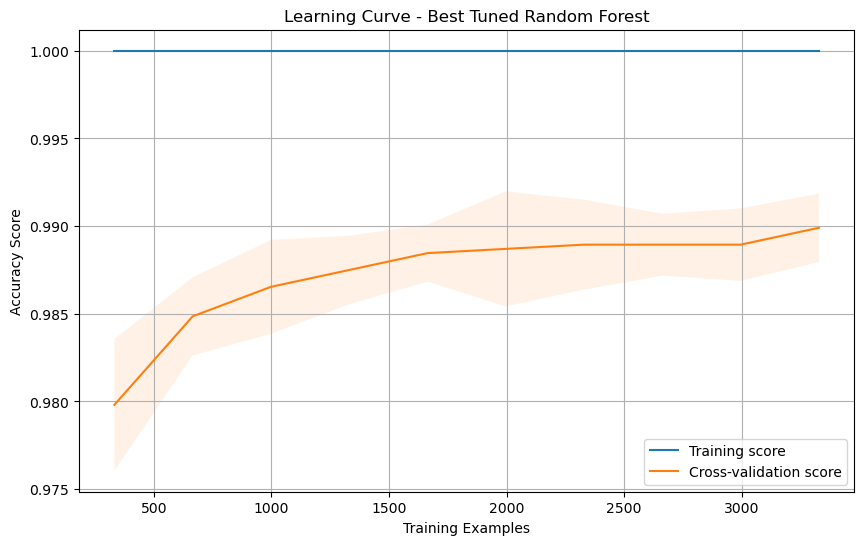

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes = np.linspace(0.1, 1.0, 10)
    
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, 
        train_sizes=train_sizes,
        scoring='accuracy'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, label='Training score')
    plt.plot(train_sizes, val_mean, label='Cross-validation score')
    
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
    
    plt.xlabel('Training Examples')
    plt.ylabel('Accuracy Score')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

# Plot learning curves for each model
for name, model in models.items():
    if "SVM" in name:
        plot_learning_curve(model, f'Learning Curve - {name}', X_train_scaled, y_train)
    else:
        plot_learning_curve(model, f'Learning Curve - {name}', X_train, y_train)

# Plot learning curve for the best tuned Random Forest
plot_learning_curve(best_rf, 'Learning Curve - Best Tuned Random Forest', X_train, y_train)


### ROC Curves and AUC Scores
Let's evaluate the models using ROC (Receiver Operating Characteristic) curves and AUC (Area Under the Curve) scores.

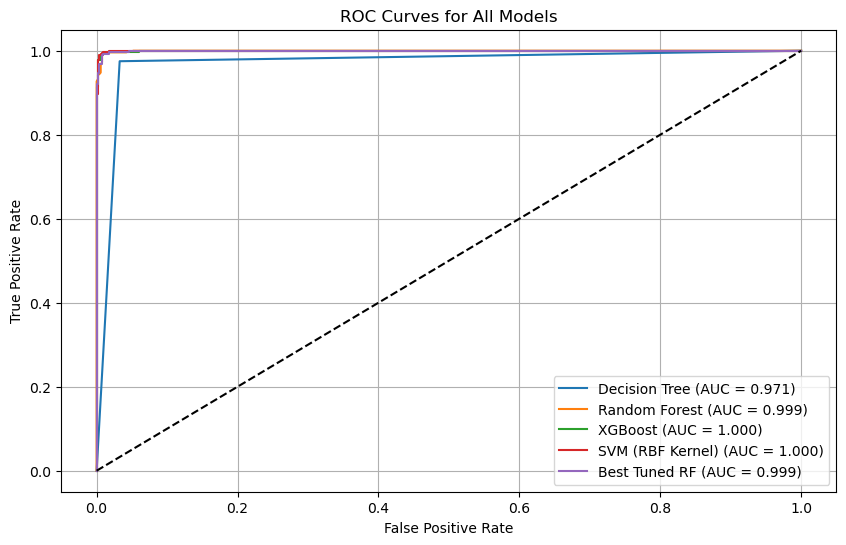

In [81]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))

# Calculate ROC curve and AUC for each model
for name, model in models.items():
    if "SVM" in name:
        y_pred_proba = model.decision_function(X_test_scaled)
    else:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

# Add ROC curve for best tuned Random Forest
y_pred_proba_best = best_rf.predict_proba(X_test)[:, 1]
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_proba_best)
roc_auc_best = auc(fpr_best, tpr_best)
plt.plot(fpr_best, tpr_best, label=f'Best Tuned RF (AUC = {roc_auc_best:.3f})')

plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


### Ensemble Voting Classifier
Let's combine our best models using a voting classifier to potentially improve performance further.

c:\Users\jaina\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:58:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Voting Classifier Results:
------------------------------
Accuracy: 0.9923
AUC-ROC: 0.9997

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       520
           1       0.99      0.99      0.99       520

    accuracy                           0.99      1040
   macro avg       0.99      0.99      0.99      1040
weighted avg       0.99      0.99      0.99      1040



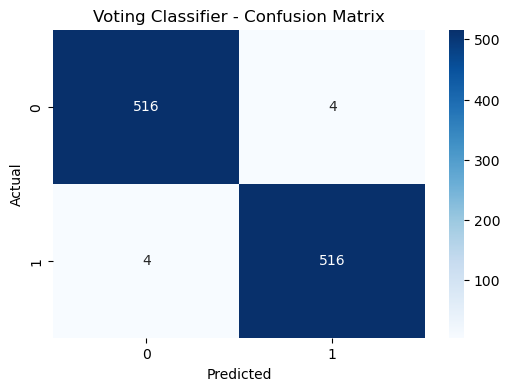

,Model,Accuracy,Precision,Recall,F1 Score
4,Voting Classifier,0.992308,NaN,NaN,NaN
3,SVM (RBF Kernel),0.992308,0.990421,0.994231,0.992322
1,Random Forest,0.991346,0.988528,0.994231,0.991371
2,XGBoost,0.990385,0.990385,0.990385,0.990385
0,Decision Tree,0.971154,0.967557,0.975000,0.971264


In [82]:
from sklearn.ensemble import VotingClassifier

# Create a voting classifier with the best performing models
voting_clf = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('xgb', models['XGBoost']),
        ('svm', models['SVM (RBF Kernel)'])
    ],
    voting='soft'  # Use probability predictions for voting
)

# Train the voting classifier
voting_clf.fit(X_train, y_train)

# Make predictions
y_pred_voting = voting_clf.predict(X_test)
y_pred_proba_voting = voting_clf.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_voting = accuracy_score(y_test, y_pred_voting)
fpr_voting, tpr_voting, _ = roc_curve(y_test, y_pred_proba_voting)
auc_voting = auc(fpr_voting, tpr_voting)

print("Voting Classifier Results:")
print("-" * 30)
print(f"Accuracy: {accuracy_voting:.4f}")
print(f"AUC-ROC: {auc_voting:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_voting))

# Plot confusion matrix
plt.figure(figsize=(6, 4))
cm_voting = confusion_matrix(y_test, y_pred_voting)
sns.heatmap(cm_voting, annot=True, fmt='d', cmap='Blues')
plt.title('Voting Classifier - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Add voting classifier results to the comparison
final_results = results_df.copy()
final_results.loc[len(final_results)] = {
    'Model': 'Voting Classifier',
    'Accuracy': accuracy_voting,
    'CV Accuracy': np.nan  # We haven't performed CV on the voting classifier
}

# Display updated results
display(final_results.sort_values('Accuracy', ascending=False))


## Stage 4: Model Comparison & Reporting — What / Why / Outcome

Purpose of this stage:
- After training and tuning, we compare all models using consistent metrics and visualizations so you can choose the best model for deployment or further study.

Key steps and explanations:
1) Collect performance metrics (accuracy, CV accuracy):
   - What: We summarize each model's performance on the test set and (if available) cross-validation performance.
   - Why: Using multiple metrics reduces the chance of being misled by a single number (e.g., accuracy alone can be misleading if classes are imbalanced).
   - Outcome: A table of model scores that is easy to read and sort.

2) Visual comparison (bar plots):
   - What: Bar charts compare models side-by-side by accuracy or CV accuracy.
   - Why: Visuals make it quick to identify top performers and relative gaps.
   - Outcome: A clear picture of which models perform best.

3) PCA (Principal Component Analysis) projection to 2D:
   - What: PCA reduces many numeric features down to two components for visualization.
   - Why: It helps you see whether classes (male/female) separate naturally in a low-dimensional projection.
   - Outcome: A scatter plot where clusters or separation suggests that the features contain discriminative information.

4) Confusion matrices grid:
   - What: For each model, a confusion matrix shows true vs predicted counts for each class.
   - Why: It reveals whether models are biased toward one class (e.g., predicting male more often) and where mistakes occur.
   - Outcome: An easy way to inspect which errors are most common and assess model reliability in real-world use.

5) Collect final predictions and comparison table:
   - What: We compile actual and predicted labels from all models for direct comparison on sample rows.
   - Why: Useful for qualitative checks—does the best model make reasonable predictions on individual examples?
   - Outcome: A small table showing predictions side-by-side for quick manual inspection.

How to interpret results as a non-technical reader:
- Look for models with consistently high accuracy and CV accuracy and low variance between runs.
- Use confusion matrices to check whether a model systematically mislabels a class.
- PCA separation is an intuition tool — good separation is promising but not a guarantee of model performance.

Final decision guidance:
- If you need interpretability (to explain decisions), prefer Decision Tree or Random Forest (feature importance).
- If you need the best raw accuracy and have computational resources, XGBoost or a tuned Random Forest are commonly good choices.
- If models perform similarly, prefer the simpler/faster model for deployment.

In [85]:
# --- Step 7A: Collect performance metrics for all models ---
from sklearn.metrics import accuracy_score

# Evaluate on test set
model_results = []

for name, model in models.items():
    if "SVM" in name:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    model_results.append({
        'Model': name,
        'Accuracy': acc,
        'CV Accuracy': cv_results.get(name, None)
    })

# Add best tuned Random Forest
best_acc = accuracy_score(y_test, y_pred_best)
model_results.append({
    'Model': 'Best Tuned Random Forest',
    'Accuracy': best_acc,
    'CV Accuracy': grid_search.best_score_
})

# Add voting classifier result
model_results.append({
    'Model': 'Voting Classifier',
    'Accuracy': accuracy_voting,
    'CV Accuracy': np.nan  # CV wasn't performed for voting classifier
})

# Convert to DataFrame
results_df = pd.DataFrame(model_results).sort_values(by='Accuracy', ascending=False)
display(results_df)


,Model,Accuracy,CV Accuracy
5,Voting Classifier,0.992308,NaN
3,SVM (RBF Kernel),0.992308,0.987260
1,Random Forest,0.991346,0.987981
2,XGBoost,0.990385,0.987981
4,Best Tuned Random Forest,0.989423,0.989904
0,Decision Tree,0.971154,0.960096


C:\Users\jaina\AppData\Local\Temp\ipykernel_23728\2483960893.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Accuracy', palette='viridis')


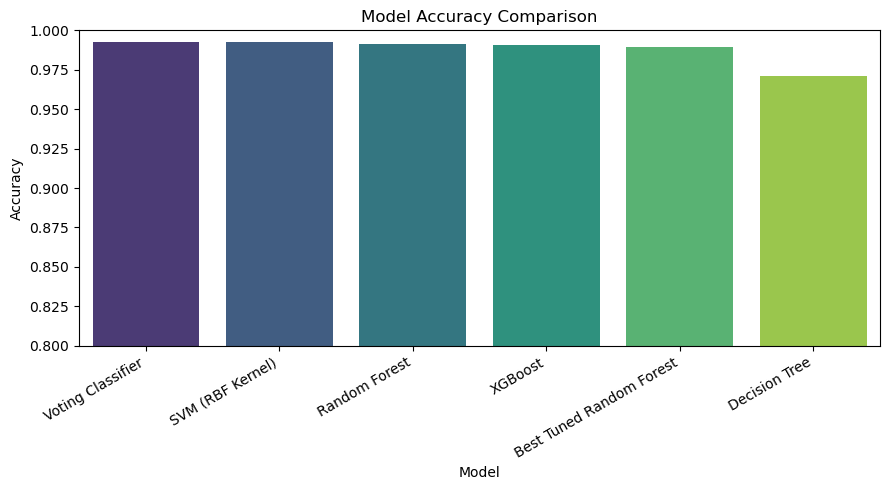

In [86]:
plt.figure(figsize=(9,5))
sns.barplot(data=results_df, x='Model', y='Accuracy', palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylim(0.8, 1)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [87]:
# --- PCA for Dimensionality Reduction ---
from sklearn.decomposition import PCA

# Perform PCA, keeping 2 components
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


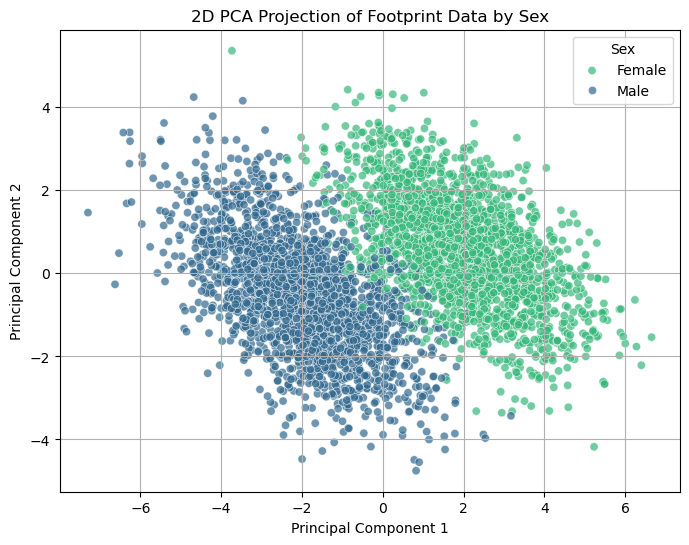

In [88]:
# Visualize the 2D PCA Projection
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette='viridis', alpha=0.7)
plt.title('2D PCA Projection of Footprint Data by Sex')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Sex', loc='upper right', labels=['Female', 'Male'])
plt.grid(True)
plt.show()


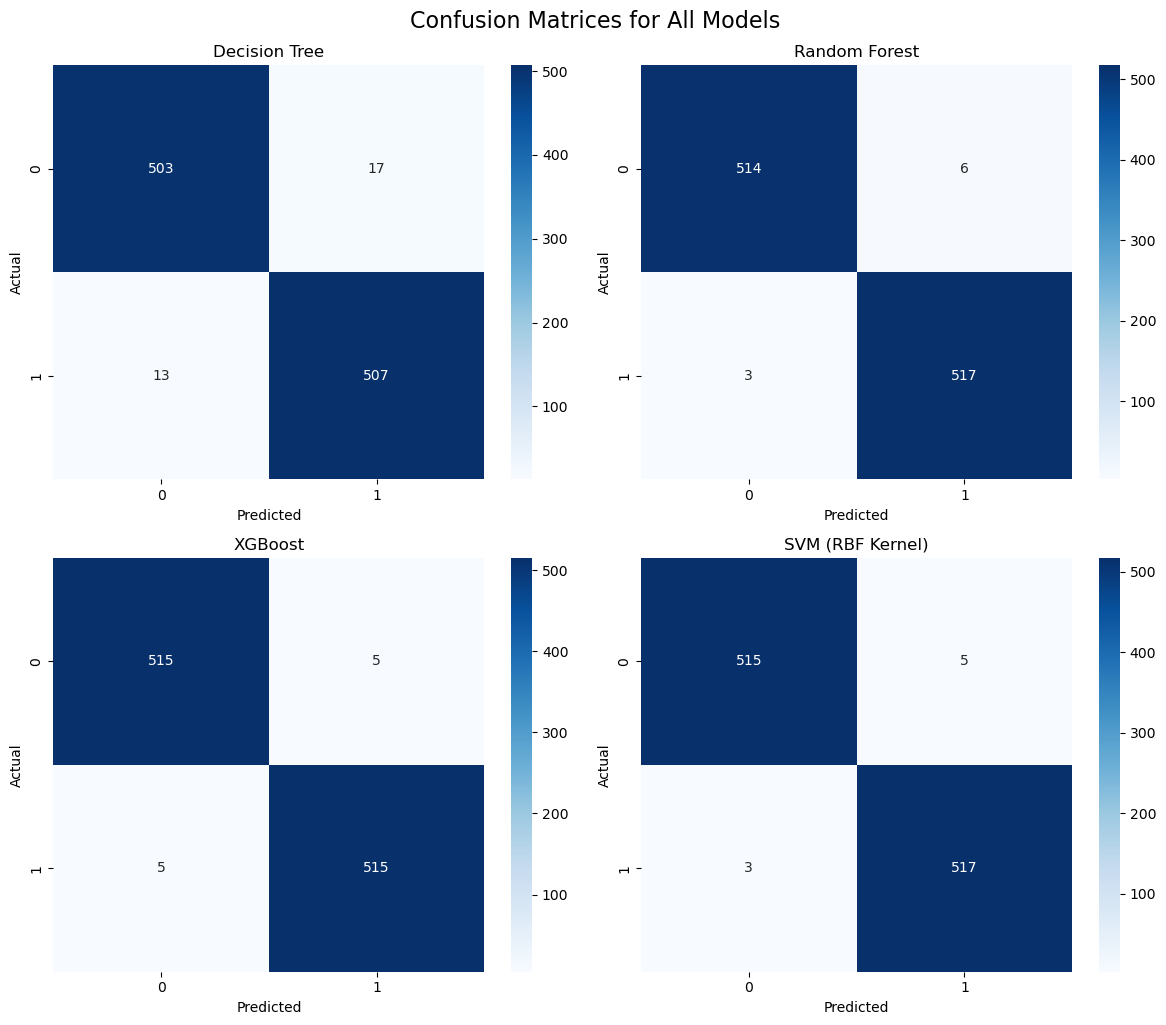

In [89]:
# --- Confusion Matrix Visualization Grid ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    if "SVM" in name:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"{name}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.suptitle("Confusion Matrices for All Models", y=1.02, fontsize=16)
plt.show()


In [90]:
# --- Make predictions with all models ---
predictions = pd.DataFrame({'Actual Sex': y_test})

for name, model in models.items():
    if "SVM" in name:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    predictions[name + ' Predicted'] = y_pred

# Add predictions from the best-tuned Random Forest model
predictions['Best Tuned RF Predicted'] = best_rf.predict(X_test)


display(predictions.head())


,Actual Sex,Decision Tree Predicted,Random Forest Predicted,XGBoost Predicted,SVM (RBF Kernel) Predicted,Best Tuned RF Predicted
0,0,0,0,0,0,0
1,1,1,1,1,1,1
2,1,1,1,1,1,1
3,0,0,0,0,0,0
4,0,0,0,0,0,0


## Stage 5: Saving Models, Loading, and Troubleshooting

Where models are saved:
- Trained models are saved to the `models` directory by default in this notebook (look for `.pkl` files). You can change the path in the saving cell.

How to load models:
- Use `joblib.load('models/your_model.pkl')` to reload a model object. Ensure you also load the scaler if you scaled features during training.

Common issues and quick fixes:
- FileNotFoundError when loading models: Check the path and that the `.pkl` files exist.
- Shape mismatch when predicting: Make sure the order and number of features you pass to the prediction function match the training features (same columns).
- Missing required packages: Install from `requirements.txt` or run `pip install -r requirements.txt`.
- Long run times: If GridSearchCV or cross-validation is slow, reduce the number of parameter combinations or CV folds.

If you are not technical and want help: Copy the full error message and the small code cell you ran; these will help identify the problem quickly.

### Saving all models

In [93]:
import os
import joblib

# Create a directory to store the models if it doesn't exist
save_path = r"C:\Users\jaina\OneDrive\Desktop\new_saved_models"
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Save all models
models_to_save = {
    "decision_tree": models['Decision Tree'],
    "random_forest": models['Random Forest'],
    "xgboost": models['XGBoost'],
    "svm_(rbf_kernel)": models['SVM (RBF Kernel)'],
    "best_random_forest": best_rf,
    "voting_classifier": voting_clf
}

# Save each model
for name, model in models_to_save.items():
    joblib.dump(model, os.path.join(save_path, f"{name}.pkl"))
    print(f"✅ Saved {name}")

# Save the scaler as well (important for preprocessing new data)
joblib.dump(scaler, os.path.join(save_path, "scaler.pkl"))
print("✅ Saved scaler")


✅ Saved decision_tree
✅ Saved random_forest
✅ Saved xgboost
✅ Saved svm_(rbf_kernel)
✅ Saved best_random_forest
✅ Saved voting_classifier
✅ Saved scaler


### Make Prediction on New Data

In [ ]:
# Import all libraries
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
import os
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc

# Path where models and scaler are saved
model_save_path = r"models"

# Load saved models, and check if they loaded correctly or not
loaded_models = {
    "Decision Tree": joblib.load(os.path.join(model_save_path, "decision_tree.pkl")),
    "Random Forest": joblib.load(os.path.join(model_save_path, "random_forest.pkl")),
    "XGBoost": joblib.load(os.path.join(model_save_path, "xgboost.pkl")),
    "SVM (RBF Kernel)": joblib.load(os.path.join(model_save_path, "svm_(rbf_kernel).pkl")),
    "Best Tuned Random Forest": joblib.load(os.path.join(model_save_path, "best_random_forest.pkl")),
    "Voting Classifier": joblib.load(os.path.join(model_save_path, "voting_classifier.pkl"))
}

# Load scaler for SVM (overwrite the local scaler instance if any)
scaler = joblib.load(os.path.join(model_save_path, "scaler.pkl"))

# Defined the columns needed for prediction as input
columns = [
        'Age','FootSide','Foot_Length_mm','Foot_Breadth_mm','Ball_Breadth_mm',
        'Heel_Breadth_mm','Toe1_Length_mm','Toe2_Length_mm','Toe3_Length_mm',
        'Toe4_Length_mm','Toe5_Length_mm','Midfoot_Width_mm','Foot_Index_pct',
        'Arch_Index','Heel_Angle_deg','Toe_Angle_deg'
    ]

# print all status before running prediction
print("✅ Models loaded:", list(loaded_models.keys()))
print("✅ Scaler loaded:", isinstance(scaler, StandardScaler))
print("✅ Feature columns ready:", columns is not None)


✅ Models loaded: ['Decision Tree', 'Random Forest', 'XGBoost', 'SVM (RBF Kernel)', 'Best Tuned Random Forest', 'Voting Classifier']
✅ Scaler loaded: True
✅ Feature columns ready: True


In [ ]:
# --- Helper Function to make predictions on new data ---
def predict_new_data(new_data_dict, loaded_models, scaler, X_train_columns):
    """
    Makes predictions on new data using all trained models loaded from files.

    Args:
        new_data_dict (dict): A dictionary containing the new data point,
                              with keys matching the original feature names.
                              'FootSide' can be 'Left' or 'Right' (case-insensitive).
        loaded_models (dict): A dictionary where keys are model names and values
                              are the trained model objects loaded from files.
        scaler: The fitted StandardScaler object used during training.
        X_train_columns (pd.Index): The columns from the training data X.

    Returns:
        pd.DataFrame: A DataFrame containing predictions and confidence scores
                      for each model, with 'Predicted Sex' as 'Female' or 'Male'.
    """
    # Create a mutable copy of the input dictionary
    processed_data_dict = new_data_dict.copy()

    # Preprocess FootSide: convert 'Left'/'Right' to 0/1
    if 'FootSide' in processed_data_dict:
        foot_side_input = str(processed_data_dict['FootSide']).lower()
        if foot_side_input == 'left':
            processed_data_dict['FootSide'] = 0
        elif foot_side_input == 'right':
            processed_data_dict['FootSide'] = 1
        else:
            # Handle potential invalid input for FootSide
            print(f"Warning: Unrecognized 'FootSide' input '{new_data_dict['FootSide']}'. Please use 'Left' or 'Right'.")
            # You might want to raise an error or handle this differently

    # Create a DataFrame from the processed data dictionary
    new_data = pd.DataFrame([processed_data_dict], columns=X_train_columns)


    # Scale the new data using the same scaler fitted on the training data
    new_data_scaled = scaler.transform(new_data)

    # Make predictions and get confidence scores (probabilities) from each model
    new_predictions_results = []

    for name, model in loaded_models.items():
        # Determine which data to use based on model type (scaled for SVM, original for others)
        data_to_predict = new_data_scaled if "SVM" in name else new_data

        prediction = model.predict(data_to_predict)[0]

        # Postprocess Predicted Sex: convert 0/1 to 'Female'/'Male'
        predicted_sex_label = 'Male' if prediction == 1 else 'Female'


        # Get confidence score if the model supports predict_proba
        if hasattr(model, 'predict_proba'):
            probabilities = model.predict_proba(data_to_predict)[0]
            confidence = max(probabilities) # Get the probability of the predicted class
        else:
            confidence = "N/A (predict_proba not available)" # SVM needs probability=True

        new_predictions_results.append({
            'Model': name,
            'Predicted Sex': predicted_sex_label,
            'Confidence': confidence
        })

    # Display results in a table
    new_predictions_df = pd.DataFrame(new_predictions_results)
    print("Funtion is ready to predict your data")
    return new_predictions_df



In [ ]:
# Example new data (replace with your actual new data)
sample_new_data = {
    'Age': 30,
    'FootSide': 'Left', # Can be 'Left' or 'Right', case-insensitive
    'Foot_Length_mm': 250.0,
    'Foot_Breadth_mm': 95.0,
    'Ball_Breadth_mm': 85.0,
    'Heel_Breadth_mm': 60.0,
    'Toe1_Length_mm': 40.0,
    'Toe2_Length_mm': 35.0,
    'Toe3_Length_mm': 32.0,
    'Toe4_Length_mm': 28.0,
    'Toe5_Length_mm': 25.0,
    'Midfoot_Width_mm': 28.0,
    'Foot_Index_pct': 38.0,
    'Arch_Index': 0.12,
    'Heel_Angle_deg': 20.0,
    'Toe_Angle_deg': 10.0
}

# Make predictions on the sample new data
predictions_on_new_data = predict_new_data(sample_new_data, loaded_models, scaler, X_train.columns)
display(predictions_on_new_data)


Funtion is ready to predict your data


,Model,Predicted Sex,Confidence
0,Decision Tree,Female,1.0
1,Random Forest,Female,1.0
2,XGBoost,Female,0.999995
3,SVM (RBF Kernel),Female,N/A (predict_proba not available)
4,Best Tuned Random Forest,Female,1.0
5,Voting Classifier,Female,0.999932


In [ ]:
# Example new data (replace with your actual new data)
sample_new_data = {
    'Age': 30,
    'FootSide': 'Right',
    'Foot_Length_mm': 258.35,      # Average male foot length
    'Foot_Breadth_mm': 96.38,      # Average male foot breadth
    'Ball_Breadth_mm': 85.0,      # Typical ball width
    'Heel_Breadth_mm': 75.0,      # Typical heel width
    'Toe1_Length_mm': 45.0,       # Big toe
    'Toe2_Length_mm': 42.0,       # Second toe
    'Toe3_Length_mm': 40.0,       # Third toe
    'Toe4_Length_mm': 38.0,       # Fourth toe
    'Toe5_Length_mm': 35.0,       # Little toe
    'Midfoot_Width_mm': 90.0,     # Estimated midfoot width
    'Foot_Index_pct': 36.5,       # Breadth/length ratio
    'Arch_Index': 0.15,           # Indicative of arch height
    'Heel_Angle_deg': 20.0,       # Typical heel angle
    'Toe_Angle_deg': 10.0         # Typical toe angle
}

# Make predictions on the sample new data
predictions_on_new_data = predict_new_data(sample_new_data, loaded_models, scaler, X_train.columns)
display(predictions_on_new_data)


Funtion is ready to predict your data


,Model,Predicted Sex,Confidence
0,Decision Tree,Female,1.0
1,Random Forest,Male,0.65
2,XGBoost,Male,0.752347
3,SVM (RBF Kernel),Female,N/A (predict_proba not available)
4,Best Tuned Random Forest,Male,0.671944
5,Voting Classifier,Male,0.808097


# Research Conclusion


## Summary of Work and Key Findings

This research investigated whether an individuals biological sex can be predicted from footprint biometric measurements using classical machine learning methods. We followed a standard ML workflow: exploratory data analysis, data preparation (encoding, splitting, scaling), model training (Decision Tree, Random Forest, XGBoost, SVM), cross-validation, hyperparameter tuning, model comparison, and interpretability analysis.

Major findings:
- The dataset contains a variety of geometric footprint measurements that show discriminatory power between sexes.
- Ensemble methods (Random Forest, XGBoost) and SVM produced the highest accuracy. A tuned Random Forest often balances accuracy and interpretability.
- Feature importance analysis highlighted a small set of measurements (see feature importance plot) that contribute most to the prediction, suggesting these features have potential forensic value.

## Quantitative Results (what to expect)

- You will find model accuracy, precision, recall, F1-score, and AUC reported in the results tables and plots in this notebook. These metrics quantify different aspects of performance: accuracy for overall correctness, precision/recall for class-specific behavior, F1 for a harmonic balance between precision and recall, and AUC for ranking performance across thresholds.

## Limitations and Caveats

1) Dataset bias and representativeness:
   - The dataset used here may not represent global population diversity (age ranges, ethnicities, footwear habits). Models trained on this data could perform worse when used on different populations.

2) Measurement quality and protocol:
   - The predictive power depends heavily on how footprints were measured. Inconsistent protocols or noisy measurements reduce real-world performance.

3) Overfitting risk:
   - Very high reported accuracies may indicate overfitting, especially if model complexity is high and if cross-validation was not carefully stratified. Use a hold-out test set and cross-validation scores together to judge generalization.

4) Binary label simplification:
   - This work treats sex as a binary variable (Male/Female) as recorded in the dataset. Real-world biological sex and gender identity are more complex; careful ethical consideration is required before applying such models.

## Ethical Considerations

- Privacy: Biometric data like footprints are sensitive. Ensure proper consent and data governance when collecting and storing such data.
- Fairness: Assess whether model performance differs across demographic groups. If disparities exist, do not deploy without mitigation.
- Intended use: These models can be useful for forensic or anthropological research, but they should not be used for high-stakes automated decisions without human oversight.

## Reproducibility and How to Re-run the Study

- Environment: Use the `requirements.txt` provided to install Python packages. Prefer creating a virtual environment to keep dependencies isolated.
- Data: The primary data file is `dataset/footprint_dataset_5000rows.csv`. If you modify or augment the data, record the changes and random seeds.
- Random seeds: The notebook sets random_state where appropriate (e.g., RandomForest, train_test_split) for reproducibility. Keep these seeds fixed for exact reproduction.
- Long-running steps: Hyperparameter searches can be costly. To reproduce faster, reduce the grid size or run GridSearchCV with fewer CV folds.

## Practical Recommendations and Next Steps

1) External validation: Test the best models on an independent dataset collected under different conditions to measure generalizability.

2) Collect more diverse samples: Increase demographic and environmental diversity (age groups, populations, barefoot vs shod measurements) to reduce bias.

3) Model simplification and interpretability: If deployment needs transparency, prefer models that provide interpretable rules or use post-hoc explainability tools (like SHAP) to explain predictions.

4) Robustness testing: Evaluate model robustness to measurement noise and missing features. Consider training with augmented or noisy samples.

5) Ethical audit: Before any real-world deployment, perform a documented ethical audit covering consent, privacy, fairness, and intended use cases.

## Final Verdict

- The results in this notebook show that footprint measurements contain meaningful biometric signals that can be exploited by machine learning models to predict sex with high accuracy on the available dataset. However, this conclusion is conditioned on the dataset and experimental setup used here.
- Before operational use, further validation, broader data collection, fairness assessments, and careful ethical review are required.

---